In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

Processando Experimento n - só geometria...
['fase2_fold_1', 'fase2_fold_2', 'fase2_fold_3', 'fase2_fold_4', 'fase2_fold_5']
Processando Experimento n - geometria + intensidade...
['fase2_fold_1', 'fase2_fold_2', 'fase2_fold_3', 'fase2_fold_4', 'fase2_fold_5']
Processando Experimento 4n - só geometria...
['fase2_fold_1', 'fase2_fold_2', 'fase2_fold_3', 'fase2_fold_4', 'fase2_fold_5']
Processando Experimento 4n - geometria + intensidade...
['fase2_fold_1', 'fase2_fold_2', 'fase2_fold_3', 'fase2_fold_4', 'fase2_fold_5']
Processando Experimento 8n - só geometria...
['fase2_fold_1', 'fase2_fold_2', 'fase2_fold_3', 'fase2_fold_4', 'fase2_fold_5']
Processando Experimento 8n - geometria + intensidade...
['fase2_fold_1', 'fase2_fold_2', 'fase2_fold_3', 'fase2_fold_4', 'fase2_fold_5']


/tmp/ipykernel_749857/2947041890.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Experimento', y='Valor', data=df_final, order=order, palette='viridis', width=0.4)


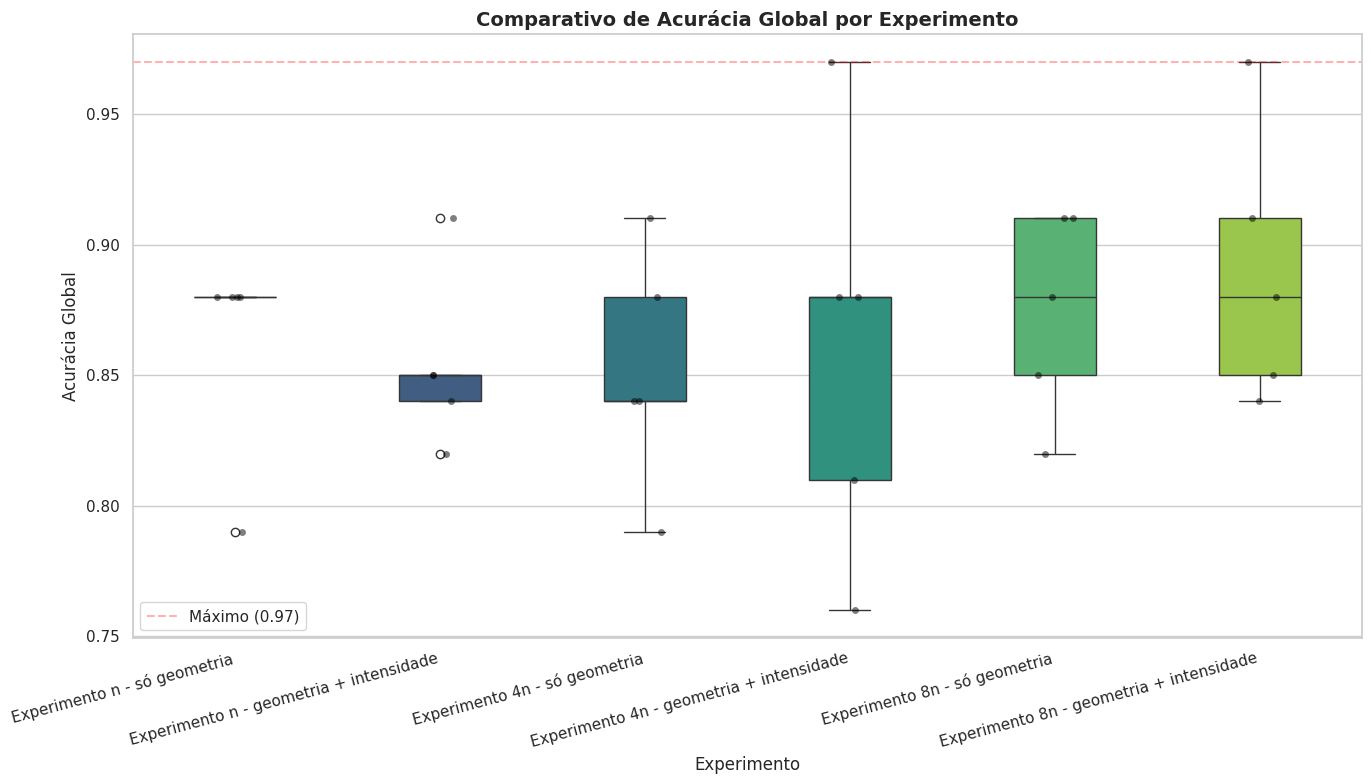

In [3]:
def extract_metric_from_txt(file_path, target_row='accuracy', target_column='f1-score'):
    """
    Extrai uma métrica específica de um classification_report em formato .txt
    """
    if not os.path.exists(file_path):
        return None
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        # Limpa espaços extras para facilitar a busca
        clean_line = " ".join(line.split())
        
        # Caso 1: Acurácia Global (formato: accuracy 0.88 163)
        if target_row == 'accuracy' and clean_line.startswith('accuracy'):
            parts = clean_line.split()
            return float(parts[1])
        
        # Caso 2: Linhas de classe ou médias (0, 1, macro avg, weighted avg)
        if clean_line.startswith(target_row):
            parts = clean_line.split()
            # No report do sklearn: [nome, precision, recall, f1-score, support]
            # Se for 'macro avg', o nome ocupa os dois primeiros índices
            offset = 1 if 'avg' in target_row else 0
            
            if target_column == 'precision': return float(parts[1 + offset])
            if target_column == 'recall':    return float(parts[2 + offset])
            if target_column == 'f1-score':  return float(parts[3 + offset])
            
    return None

def generate_experiment_boxplot(experiment_paths, target_row='accuracy', target_column='f1-score'):
    """
    Gera boxplots lendo dados de arquivos .txt de cada fold.
    """
    data_list = []

    for exp_name, base_path in experiment_paths.items():
        if not os.path.exists(base_path):
            print(f"Erro: Pasta não encontrada: {base_path}")
            continue
            
        print(f"Processando {exp_name}...")
        
        # Localiza subpastas de fold
        fold_dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d)) and d.startswith('fase2_fold')]
        print(fold_dirs)
        
        for fold in fold_dirs:
            # Tenta encontrar o arquivo .txt dentro da pasta do fold
            fold_path = os.path.join(base_path, fold)
            # Busca qualquer arquivo .txt que comece com 'report'
            txt_files = [f for f in os.listdir(fold_path) if f.endswith('.txt') and 'report' in f]
            
            if txt_files:
                report_path = os.path.join(fold_path, txt_files[0])
                val = extract_metric_from_txt(report_path, target_row, target_column)
                
                if val is not None:
                    data_list.append({
                        'Experimento': exp_name,
                        'Valor': val,
                        'Fold': fold
                    })
            else:
                print(f"      Aviso: Report .txt não encontrado em {fold_path}")

    df_final = pd.DataFrame(data_list)

    if df_final.empty:
        print("Nenhum dado extraído. Verifique os caminhos e o conteúdo dos arquivos .txt.")
        return

    # Visualização
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 8))
    
    # Ordem customizada para o eixo X (baseada na ordem das chaves do dicionário)
    order = list(experiment_paths.keys())
    
    ax = sns.boxplot(x='Experimento', y='Valor', data=df_final, order=order, palette='viridis', width=0.4)
    sns.stripplot(x='Experimento', y='Valor', data=df_final, order=order, color='black', alpha=0.5, size=5, jitter=True)

    # Linha do melhor resultado
    max_global = df_final['Valor'].max()
    plt.axhline(max_global, color='red', linestyle='--', alpha=0.3, label=f'Máximo ({max_global:.2f})')

    metric_label = f"{target_column} ({target_row})" if target_row != 'accuracy' else "Acurácia Global"
    plt.title(f'Comparativo de {metric_label} por Experimento', fontsize=14, fontweight='bold')
    plt.ylabel(metric_label)
    plt.xticks(rotation=15, ha='right')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('boxplot_metrics_from_txt.png')
    plt.show()

# ==========================================
# EXEMPLO DE USO
# ==========================================
# Substitua pelos paths reais das suas pastas de experimentos
caminhos_experimentos = {
    'Experimento n - só geometria': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/experimentos_oasis_augment/test_experimentos_2/post_trained',
    'Experimento n - geometria + intensidade': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/experimentos_oasis_augment/test_experimentos_1/post_trained',
    'Experimento 4n - só geometria': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/experimentos_oasis_augment/test_experimentos_3/post_trained',
    'Experimento 4n - geometria + intensidade': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/experimentos_oasis_augment/test_experimentos_4/post_trained',
    'Experimento 8n - só geometria': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/dgx_8n/test_experimentos_1/post_trained',
    'Experimento 8n - geometria + intensidade': '/mnt/c//Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/dgx_8n/test_experimentos_2/post_trained'
}

generate_experiment_boxplot(caminhos_experimentos)